In [ ]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import math
import lightgbm as lgb
import numpy as np
import os
import json
import re

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/{dataset}'
# data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

matplotlib 识别的字体名: Songti SC


In [387]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))



In [388]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df
    

In [389]:

# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace('.', '').replace('(', '').replace(')', '').replace(':', '').replace(',', '').replace('"', '').replace('\\', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names


In [390]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def bootstrap_auc_ci(y_true, y_score, B=1000, seed=2025, return_distribution=False):
    """
    Bootstrap percentile CI for ROC-AUC with stratified resampling on the test set.
    y_true: 1D array of {0,1}
    y_score: 1D array of predicted probabilities for class 1
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 原始整套测试集点估计
    auc_point = roc_auc_score(y_true, y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs = np.empty(B, dtype=float)
    for b in range(B):
        # 分层有放回采样，保持类样本量不变
        boot_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        boot_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        # 计算本次 AUC
        aucs[b] = roc_auc_score(y_true[boot_idx], y_score[boot_idx])

    # 百分位 CI
    lower, median, upper = np.percentile(aucs, [2.5, 50.0, 97.5])
    if return_distribution:
        return {"point": auc_point, "median": median, "ci95": (lower, upper), "all": aucs}
    else:
        return {"point": auc_point, "median": median, "ci95": (lower, upper)}



In [ ]:

def train(X_train, y_train, X_val, y_val):
    # 定义 Optuna 目标函数
    def objective(trial):
        # 建议超参数范围
        params = {
            'objective': 'binary',
            'metric': 'auc',
            'verbosity': -1,
            'boosting_type': 'gbdt',
            'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
            'num_leaves': trial.suggest_int('num_leaves', 20, 300, step=10),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'random_state': 42
        }
        
        # 添加类别权重处理不平衡数据（可选）
        if trial.suggest_categorical('use_scale_pos_weight', [True, False]):
            scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
            params['scale_pos_weight'] = scale_pos_weight
        
        # 训练模型
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],  # 早停防止过拟合
        )
        
        # 预测验证集概率
        y_val_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # 计算 AUC
        auc_score = roc_auc_score(y_val, y_val_pred_proba)
        
        # 由于 Optuna 默认最小化目标函数，我们返回 1 - AUC 来最大化 AUC
        return 1.0 - auc_score

    # 创建 Optuna 研究
    study = optuna.create_study(
        direction='minimize',  # 最小化目标函数 (1 - AUC)
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
    )

    # 运行优化
    print("开始超参数优化...")
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    # 输出最佳结果
    print("\n优化完成!")
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
    print("  Best params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 使用最佳参数重新训练最终模型
    print("\n使用最佳参数训练最终模型...")
    best_params = {k: v for k, v in best_trial.params.items() if k != 'use_scale_pos_weight'}
    best_params['random_state'] = 42
    best_params['objective'] = 'binary'
    best_params['verbose'] = 1

    # 如果使用了类别权重，添加回参数
    if 'use_scale_pos_weight' in best_trial.params and best_trial.params['use_scale_pos_weight']:
        best_params['scale_pos_weight'] = np.sum(y_train == 0) / np.sum(y_train == 1)

    final_model = lgb.LGBMClassifier(**best_params)
    final_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=20)],
        # verbose= 1
    )

    return [final_model,best_trial.params,best_params]

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name, key):
    # y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]

    # 最佳阈值
    best_thresh, best_auc = 0.5, 0
    for thresh in np.arange(0.1, 0.65, 0.05):
        pred_val = (y_pred_proba > thresh).astype(int)
        f1 = roc_auc_score(y, pred_val)
        if f1 > best_auc:
            best_thresh, best_auc = thresh, f1

    print(f"最佳阈值: {best_thresh:.2f}，测试集最大auc: {best_auc:.4f}")

    y_pred = (y_pred_proba >= best_thresh).astype(int)
    
    # if dataset_name == '测试':
    #     predict = [[], []]
    #     y = list(y)
    #     for i in range(len(y)):
    #         if y[i] == 0:
    #             predict[0].append(y_pred_proba[i])
    #         if y[i] == 1:
    #             predict[1].append(y_pred_proba[i])
    #     group = key.split('vs')
    #     plt.boxplot(predict)
    #     plt.xticks([1, 2], [group[0], group[1]])
    #     plt.title(key)
    #     plt.ylabel("可能性")
    #     plt.show()

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred_proba)

    res_auc = bootstrap_auc_ci(y, y_pred_proba, B=1000, seed=2025)
    print(f"AUC = {res_auc['point']:.3f} "
        f"(95% CI {res_auc['ci95'][0]:.3f}–{res_auc['ci95'][1]:.3f})")

    # res_pr = bootstrap_prauc_ci(y_true_test, y_score_test, B=1000, seed=2025)
    # print(f"PR-AUC = {res_pr['point']:.3f} "
    #     f"(95% CI {res_pr['ci95'][0]:.3f}–{res_pr['ci95'][1]:.3f})")

    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'CI': (round(res_auc['ci95'][0],4),round(res_auc['ci95'][1],4))
    }

    # 评估训练集、验证集和测试集
    # train_auc, train_acc, train_f1 = evaluate_model(final_model, X_train, y_train, "训练")
    # val_auc, val_acc, val_f1 = evaluate_model(final_model, X_val, y_val, "验证")
    # test_auc, test_acc, test_f1 = evaluate_model(final_model, X_test, y_test, "测试")

    # 可选：保存最佳模型
    # import joblib
    # joblib.dump(final_model, 'best_lgb_model.pkl')
    # print("\n最佳模型已保存为 'best_lgb_model.pkl'")

    # 可选：绘制特征重要性
    # import matplotlib.pyplot as plt

    # plt.figure(figsize=(10, 8))
    # lgb.plot_importance(final_model, max_num_features=15)
    # plt.title('Feature Importance')
    # plt.tight_layout()
    # plt.show()

In [392]:
def draw_result(y_val, y_test, val_results, test_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, thresholds = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, thresholds = roc_curve(y_test, test_results['y_pred_proba'])

    pd.DataFrame({
        "fpr": fpr_test,
        "tpr": tpr_test,
        "threshold": thresholds  
    }).to_csv(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/LightGBM/{key}/Dataset{current_dataset}_roc_curve.csv", index=False)


    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - LightGBM ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/LightGBM/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),'val_CI':val_results['CI'],
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),'test_CI':test_results['CI']}
    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/projects//脑脊液/naojiye/data/model_data4/LightGBM_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'LightGBM_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'LightGBM_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'LightGBM_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'LightGBM_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'LightGBM_Dataset{current_dataset}'][model] = data_to_append

    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)



In [ ]:
def draw_shap(final_model, X_train, X_test, current_dataset, key):

    task_trans = {
        "阴性组vs其他": "NG vs Others",
        "感染性脑膜炎vs非感染性脑膜炎": "Infectious Meningitis vs Non-Infectious ",
        "细菌性脑膜炎vs其他感染性脑膜炎": "BM vs Other Infectious Meningitis",
        "病毒性脑膜炎vs其他感染性脑膜炎": "VM vs Other Infectious Meningitis",
        "结核性脑膜炎vs其他感染性脑膜炎": "TBM vs Other Infectious Meningitis",
        "真菌性脑膜炎vs其他感染性脑膜炎": "FM vs Other Infectious Meningitis",
        "肿瘤性脑膜炎vs其他": "LM vs Others",
        "自身免疫性脑膜炎vs其他": "AE vs Others",
        "病毒性脑膜炎vs病毒性脑炎": "VM vs VE"
    }

    # ---------------- SHAP 分析 -----------------
    print(X_train.shape,X_test.shape)
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_test)
    shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

    trans_df = pd.read_excel('/Users/yanjieni/Desktop/projects/脑脊液/naojiye/ipynb/项目英文缩写与全称.xlsx')
    trans_dict = {}
    print(X_test.columns)
    for index, row in trans_df.iterrows():
        trans_dict[row['中文项目名称']] = row['英文缩写']
    # new_index = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for x in list(X_test.columns)]
    X_test = X_test.rename(columns={'血_葡萄糖空腹_定量': '血_葡萄糖[空腹]_定量'})
    X_test = X_test.rename(columns={'血_肌酸激酶.MB型质量法_定量': '血_肌酸激酶.MB型[质量法]_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD3-CD19+百分比_定量': '血_细胞.CD3-CD19+百分比_定量'})   
    X_test = X_test.rename(columns={'血_13-β-D-葡聚糖_定量': '血_1,3-β-D-葡聚糖_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD3+CD8+百分比_定量': '血_细胞.CD3+CD8+百分比_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD3+CD4+百分比_定量': '血_细胞.CD3+CD4+百分比_定量'})   
    X_test = X_test.rename(columns={'血_细胞CD4+/CD8+_定量': '血_细胞.CD4+/CD8+_定量'}) 
    X_test = X_test.rename(columns={'血_肌酸激酶MB型质量法_定量': '血_肌酸激酶.MB型[质量法]_定量'}) 
    X_test = X_test.rename(columns={'血_乙型肝炎病毒核心抗体IgM_定量': '血_乙型肝炎病毒核心抗体.IgM_定量'}) 
    X_test = X_test.rename(columns={'血_轻链κ型_定量': '血_轻链.κ型_定量'}) 
    
    
    
    X_test.columns = [x if x in ['age', 'gender'] else "_".join(x.split('_')[:-1]) for i, x in enumerate(X_test.columns)]
     
    X_test_en = X_test.rename(columns=trans_dict)
    feature_names_en = list(X_test_en.columns)

    print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
    plt.title(f"Features' Importance of {task_trans[key]} (Histogram)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    shap.summary_plot(shap_matrix, X_test, plot_type="bar", show=False, feature_names=feature_names_en)
    # plt.gca().invert_xaxis()
    # for p in plt.gca().patches:            # 柱子是 patch
    #     p.set_alpha(0.3) 
    # plt.gca().tick_params(axis='both', labelsize=22)
    # for lab in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    #     lab.set_fontweight('bold') 
    # for r in plt.gca().patches:     # 每个 r 是一个 Rectangle
    #     r.set_height(0.9) 
    # plt.xlabel("mean(|SHAP value|)", fontsize=22, fontweight='bold')
    plt.savefig(f"/Users/yanjieni/Desktop/projects//脑脊液/naojiye/images/Dataset_v3/LightGBM/shap/Dataset{current_dataset}/{key}shap柱状图.png", dpi=300, bbox_inches='tight')  # 保存为PNG       
    plt.show()

    # plt.title(f"{key}特征重要性(柱状图)", fontsize=16, fontweight='bold')
    plt.title(f"Features' Importance of {task_trans[key]} (Beeswarm Plot)", fontsize=14, fontweight='bold')
    plt.tight_layout()

    print(f"\n===== SHAP 特征分布 (蜂群图): =====")
    # max_display = 20
    # h = 0.5 * max_display + 1   # 经验公式：每个特征 ~0.5 英寸
    shap.summary_plot(shap_matrix, X_test, show=False, feature_names=feature_names_en, plot_size=(9, h))
    # plt.gca().tick_params(axis='both', labelsize=22)
    # for lab in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
    #     lab.set_fontweight('bold') 
    # plt.xlabel("SHAP value", fontsize=22, fontweight='bold')
    # # 画布与坐标轴背景透明
    # fig = plt.gcf()
    # fig.patch.set_alpha(0.0)              # 整个画布透明
    # for ax in fig.axes:
    #     ax.set_facecolor('none')          # 每个子图（含色条）背景透明

    # cbar_ax = fig.axes[-1]                 # 通常最后一个就是colorbar的轴
    # cbar_ax.tick_params(labelsize=20)      # 刻度字号
    # for lab in cbar_ax.get_yticklabels():
    #     lab.set_fontweight('bold')         # 刻度加粗
        
    # for coll in plt.gca().collections:                 # PathCollection
    #     try:
    #         coll.set_sizes([30])                # 数值越大点越大
    #     except Exception:
    #         pass
    # # 如果要把右侧的“Feature value”文字也放大加粗：
    # cbar_ax.set_ylabel("Feature value", fontsize=22, fontweight='bold')
    # plt.tight_layout()
    
    plt.savefig(f"/Users/yanjieni/Desktop/projects//脑脊液/naojiye/images/Dataset_v3/LightGBM/shap/Dataset{current_dataset}/{key}shap蜂群图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

[I 2025-11-12 19:03:54,420] A new study created in memory with name: no-name-6085d755-b7fd-4e51-a9ac-a68915ba0cc0


开始超参数优化...


Best trial: 0. Best value: 0.0279365:   2%|▏         | 2/100 [00:00<00:14,  6.75it/s]

[I 2025-11-12 19:03:54,629] Trial 0 finished with value: 0.027936507936507926 and parameters: {'n_estimators': 200, 'num_leaves': 290, 'max_depth': 10, 'learning_rate': 0.030405325392865647, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887, 'min_child_samples': 62, 'use_scale_pos_weight': True}. Best is trial 0 with value: 0.027936507936507926.
[I 2025-11-12 19:03:54,736] Trial 1 finished with value: 0.05920634920634926 and parameters: {'n_estimators': 500, 'num_leaves': 260, 'max_depth': 5, 'learning_rate': 0.002820996133514492, 'subsample': 0.6733618039413735, 'colsample_bytree': 0.721696897183815, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 7.71800699380605e-05, 'min_child_samples': 32, 'use_scale_pos_weight': True}. Best is trial 0 with value: 0.027936507936507926.


Best trial: 2. Best value: 0.0238095:   5%|▌         | 5/100 [00:00<00:10,  8.70it/s]

...

[I 2025-11-12 19:04:05,091] Trial 93 finished with value: 0.07412698412698415 and parameters: {'n_estimators': 50, 'num_leaves': 20, 'max_depth': 11, 'learning_rate': 0.0010566643865010266, 'subsample': 0.8266925805809189, 'colsample_bytree': 0.6796131290624811, 'reg_alpha': 0.0010191148045224213, 'reg_lambda': 0.16368232289291515, 'min_child_samples': 70, 'use_scale_pos_weight': True}. Best is trial 62 with value: 0.0174603174603174.
[I 2025-11-12 19:04:05,160] Trial 94 finished with value: 0.020000000000000018 and parameters: {'n_estimators': 100, 'num_leaves': 180, 'max_depth': 7, 'learning_rate': 0.24585140680903675, 'subsample': 0.8078465736279083, 'colsample_bytree': 0.6594784118686737, 'reg_alpha': 0.0005258039435515606, 'reg_lambda': 0.009801142044888835, 'min_child_samples': 79, 'use_scale_pos_weight': True}. Best is trial 62 with value: 0.0174603174603174.
[I 2025-11-12 19:04:05,221] Trial 95 finished with value: 0.0323809523809524 and parameters: {'n_estimators': 150, 'num_l

Best trial: 62. Best value: 0.0174603:  99%|█████████▉| 99/100 [00:11<00:00, 12.71it/s]

[I 2025-11-12 19:04:05,298] Trial 96 finished with value: 0.025079365079365035 and parameters: {'n_estimators': 300, 'num_leaves': 180, 'max_depth': 7, 'learning_rate': 0.1781269212527415, 'subsample': 0.8096043427929406, 'colsample_bytree': 0.6509880772046257, 'reg_alpha': 0.0001348672456121602, 'reg_lambda': 0.0033294561718295295, 'min_child_samples': 66, 'use_scale_pos_weight': True}. Best is trial 62 with value: 0.0174603174603174.
[I 2025-11-12 19:04:05,410] Trial 97 finished with value: 0.021269841269841328 and parameters: {'n_estimators': 100, 'num_leaves': 180, 'max_depth': 8, 'learning_rate': 0.12747272928320408, 'subsample': 0.7964828065346674, 'colsample_bytree': 0.637165076628774, 'reg_alpha': 0.0012782134568640154, 'reg_lambda': 0.019701514486047705, 'min_child_samples': 73, 'use_scale_pos_weight': True}. Best is trial 62 with value: 0.0174603174603174.
[I 2025-11-12 19:04:05,463] Trial 98 finished with value: 0.036190476190476106 and parameters: {'n_estimators': 50, 'num_

Best trial: 62. Best value: 0.0174603: 100%|██████████| 100/100 [00:11<00:00,  9.01it/s]


[I 2025-11-12 19:04:05,526] Trial 99 finished with value: 0.027936507936507926 and parameters: {'n_estimators': 50, 'num_leaves': 170, 'max_depth': 8, 'learning_rate': 0.10684454105297879, 'subsample': 0.7923161214711442, 'colsample_bytree': 0.6372525524564698, 'reg_alpha': 0.000287237876340336, 'reg_lambda': 0.01923123908822147, 'min_child_samples': 71, 'use_scale_pos_weight': True}. Best is trial 62 with value: 0.0174603174603174.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9825
  Best params: 
    n_estimators: 100
    num_leaves: 150
    max_depth: 4
    learning_rate: 0.1832034332926191
    subsample: 0.8296520304310523
    colsample_bytree: 0.652399078892673
    reg_alpha: 0.004957707864974467
    reg_lambda: 0.185380350786536
    min_child_samples: 75
    use_scale_pos_weight: True

使用最佳参数训练最终模型...
[LightGBM] [Info] Number of positive: 74, number of negative: 379
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001094 s

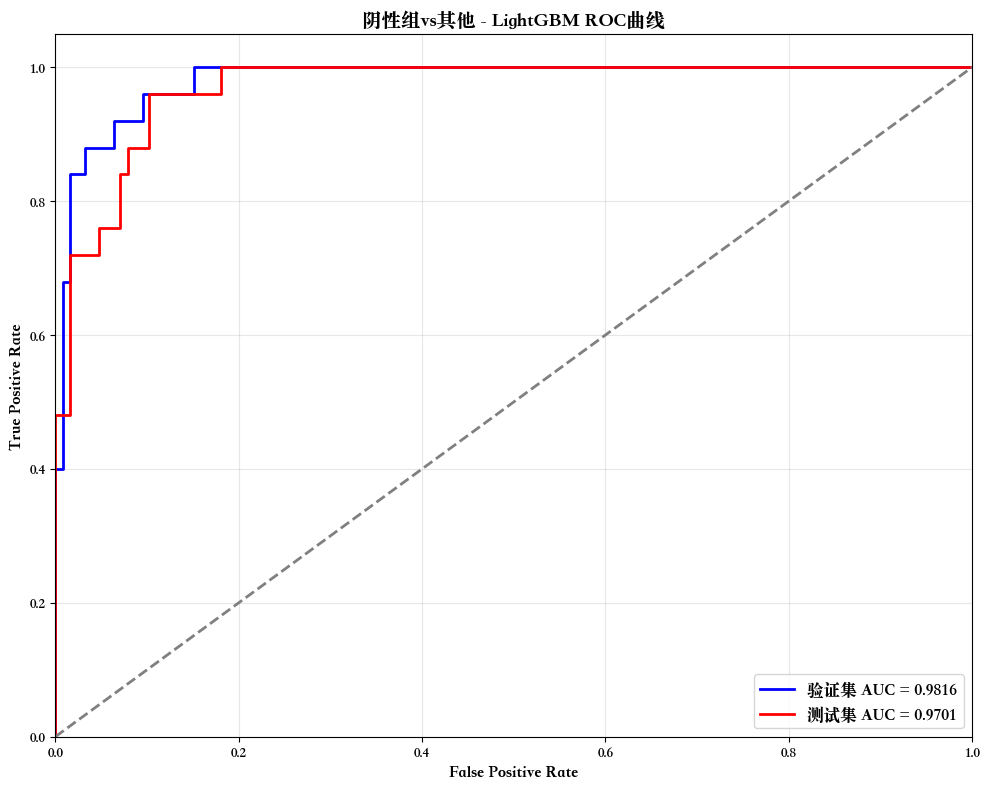

(453, 218) (152, 218)
Index(['血_13-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞CD3-CD19+百分比_定量',
       '血_细胞CD3+百分比_定量', '血_细胞CD3+CD4+百分比_定量', '血_细胞CD4+/CD8+_定量',
       '血_细胞CD3+CD8+百分比_定量', '血_细胞CD3-CD16+CD56+百分比_定量', '血_肌酸激酶MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=218)

===== SHAP 特征重要性 (柱状图):  =====


/opt/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


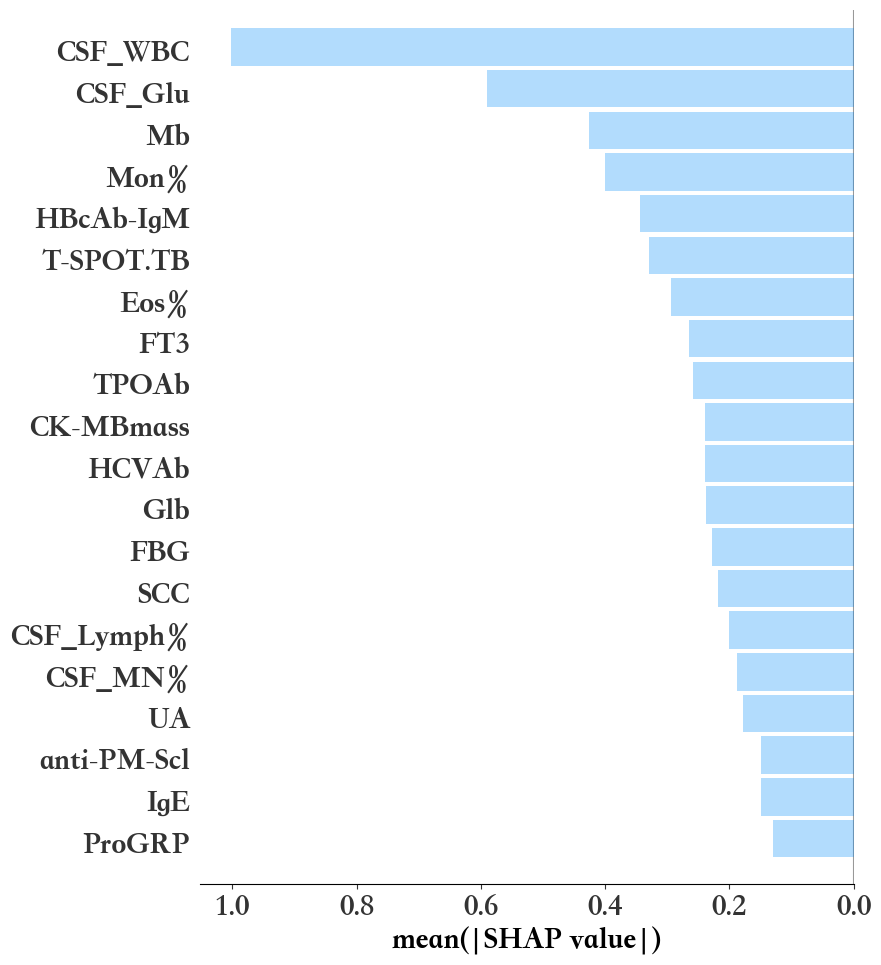


===== SHAP 特征分布 (蜂群图): =====


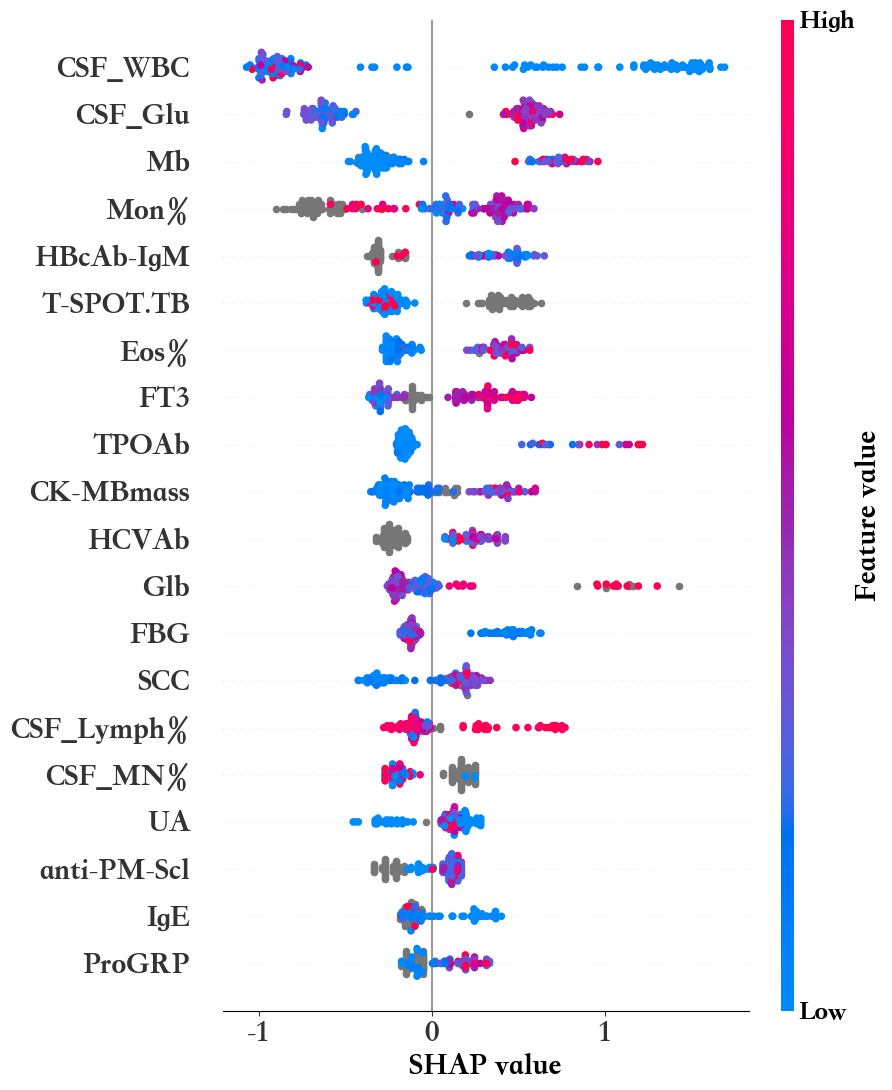

[I 2025-11-12 19:04:07,536] A new study created in memory with name: no-name-c896e245-6c15-429d-b594-4d2e0ef9fa1f


开始超参数优化...


Best trial: 0. Best value: 0.0264868:   1%|          | 1/100 [00:00<00:19,  5.09it/s]

[I 2025-11-12 19:04:07,732] Trial 0 finished with value: 0.0264867566216892 and parameters: {'n_estimators': 200, 'num_leaves': 290, 'max_depth': 10, 'learning_rate': 0.030405325392865647, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887, 'min_child_samples': 62, 'use_scale_pos_weight': True}. Best is trial 0 with value: 0.0264867566216892.


Best trial: 0. Best value: 0.0264868:   1%|          | 1/100 [00:00<00:19,  5.09it/s]

...

[I 2025-11-12 19:04:18,185] Trial 93 finished with value: 0.019490254872563728 and parameters: {'n_estimators': 200, 'num_leaves': 120, 'max_depth': 7, 'learning_rate': 0.09625170726669861, 'subsample': 0.9083483648707357, 'colsample_bytree': 0.726634370251492, 'reg_alpha': 0.010503610410548491, 'reg_lambda': 0.0006827303758523421, 'min_child_samples': 62, 'use_scale_pos_weight': True}. Best is trial 65 with value: 0.010994502748625679.


Best trial: 65. Best value: 0.0109945:  97%|█████████▋| 97/100 [00:11<00:00,  7.01it/s]

[I 2025-11-12 19:04:18,626] Trial 94 finished with value: 0.023488255872063935 and parameters: {'n_estimators': 200, 'num_leaves': 130, 'max_depth': 7, 'learning_rate': 0.10482714416733067, 'subsample': 0.9717314446629984, 'colsample_bytree': 0.7271077981893662, 'reg_alpha': 0.010851041994344278, 'reg_lambda': 0.00010523723095608067, 'min_child_samples': 54, 'use_scale_pos_weight': True}. Best is trial 65 with value: 0.010994502748625679.
[I 2025-11-12 19:04:18,692] Trial 95 finished with value: 0.02648675662168909 and parameters: {'n_estimators': 200, 'num_leaves': 150, 'max_depth': 7, 'learning_rate': 0.2721754464709594, 'subsample': 0.9188480558951759, 'colsample_bytree': 0.7686063789793749, 'reg_alpha': 0.04233504033919714, 'reg_lambda': 0.0035308826511957535, 'min_child_samples': 61, 'use_scale_pos_weight': True}. Best is trial 65 with value: 0.010994502748625679.
[I 2025-11-12 19:04:18,805] Trial 96 finished with value: 0.020239880059970128 and parameters: {'n_estimators': 250, '

Best trial: 65. Best value: 0.0109945: 100%|██████████| 100/100 [00:11<00:00,  8.64it/s]


[I 2025-11-12 19:04:18,929] Trial 97 finished with value: 0.02748625687156414 and parameters: {'n_estimators': 250, 'num_leaves': 110, 'max_depth': 5, 'learning_rate': 0.046903540529930336, 'subsample': 0.9001882721697246, 'colsample_bytree': 0.7400294754261512, 'reg_alpha': 0.014633828474477785, 'reg_lambda': 0.000615565996375324, 'min_child_samples': 64, 'use_scale_pos_weight': True}. Best is trial 65 with value: 0.010994502748625679.
[I 2025-11-12 19:04:19,020] Trial 98 finished with value: 0.02398800599700146 and parameters: {'n_estimators': 250, 'num_leaves': 100, 'max_depth': 7, 'learning_rate': 0.06941444390254171, 'subsample': 0.8857150155900961, 'colsample_bytree': 0.790955453347008, 'reg_alpha': 0.003454431619227942, 'reg_lambda': 0.0002637825172140656, 'min_child_samples': 58, 'use_scale_pos_weight': True}. Best is trial 65 with value: 0.010994502748625679.
[I 2025-11-12 19:04:19,104] Trial 99 finished with value: 0.02298850574712641 and parameters: {'n_estimators': 300, 'nu

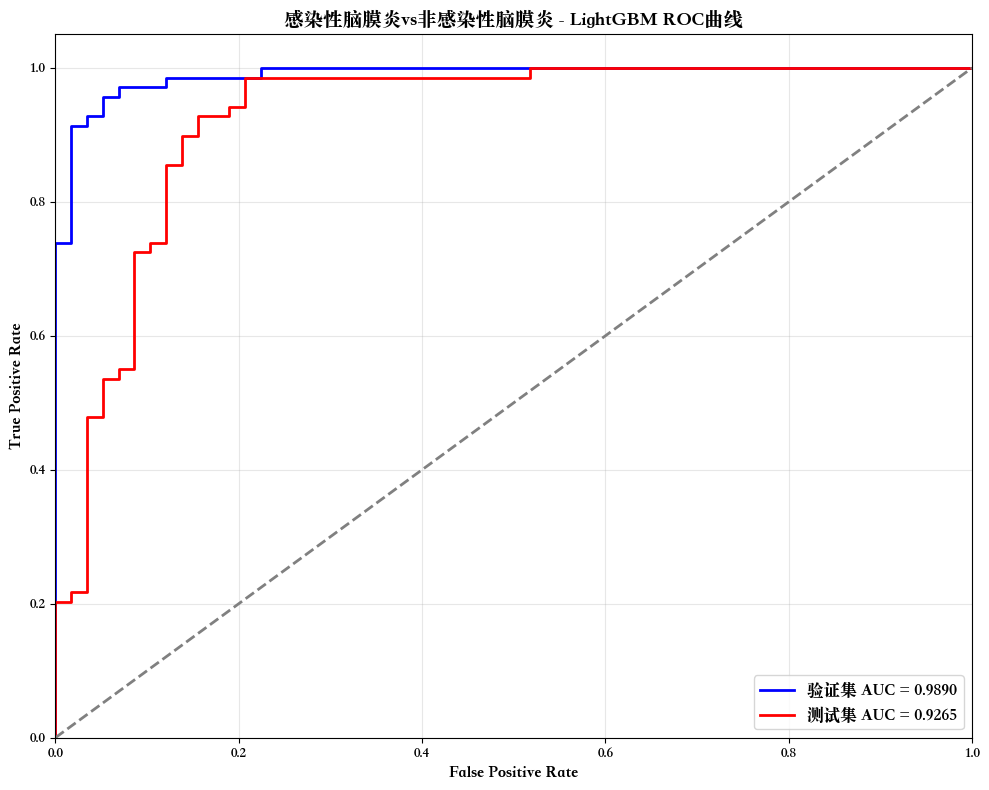

(378, 217) (127, 217)
Index(['血_13-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞CD3-CD19+百分比_定量',
       '血_细胞CD3+百分比_定量', '血_细胞CD3+CD4+百分比_定量', '血_细胞CD4+/CD8+_定量',
       '血_细胞CD3+CD8+百分比_定量', '血_细胞CD3-CD16+CD56+百分比_定量', '血_肌酸激酶MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=217)

===== SHAP 特征重要性 (柱状图):  =====


/opt/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


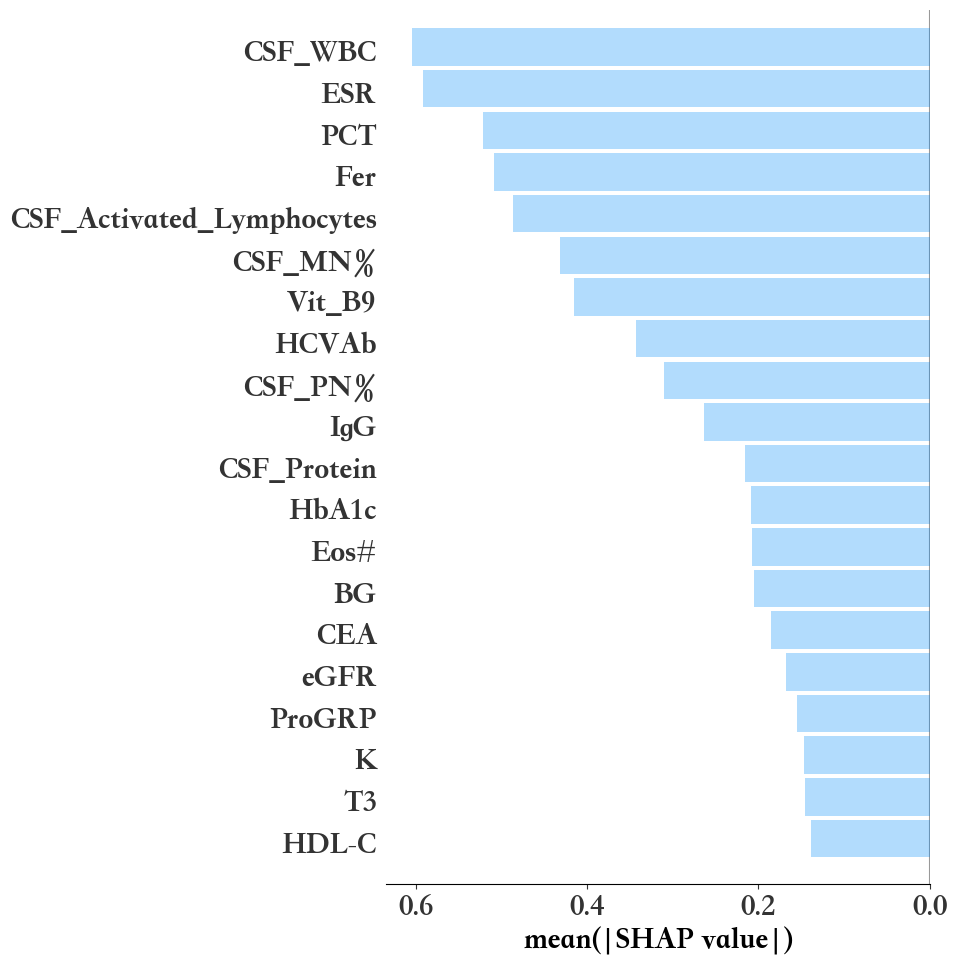


===== SHAP 特征分布 (蜂群图): =====


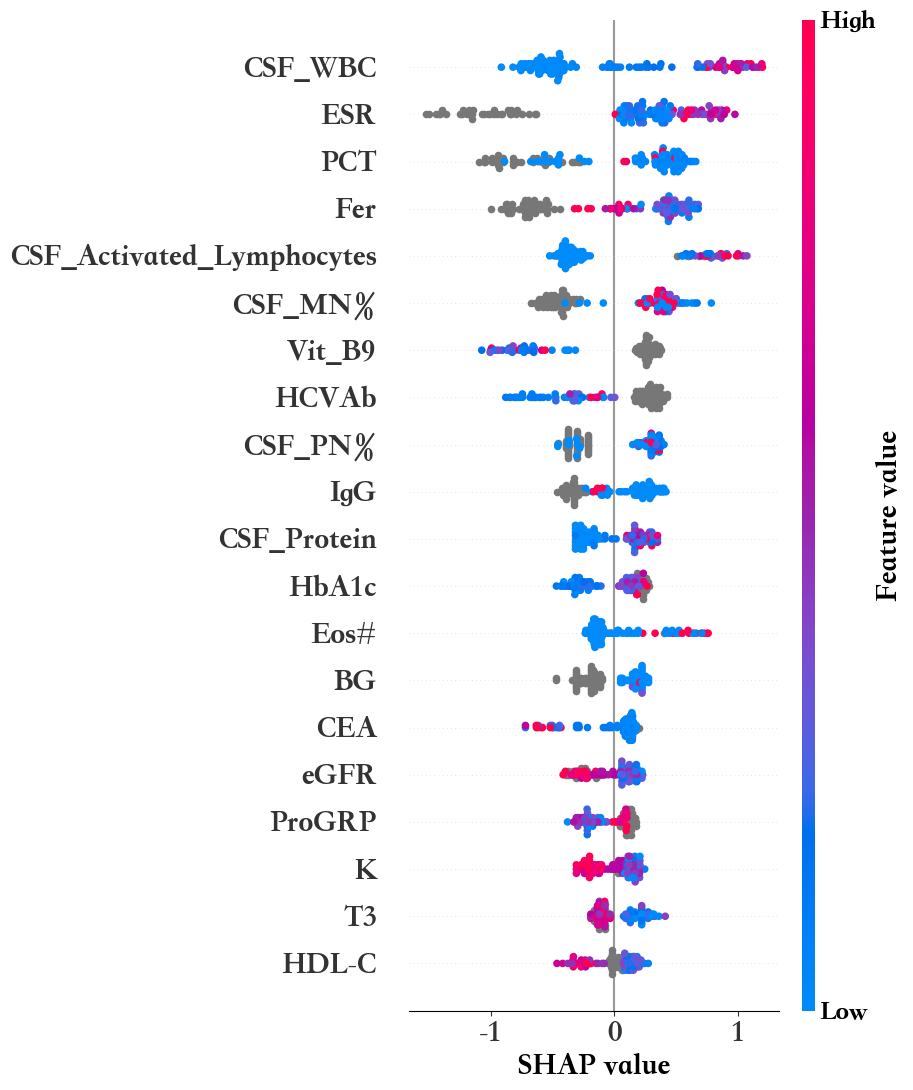

[I 2025-11-12 19:04:21,245] A new study created in memory with name: no-name-3d902cb5-c8d5-451c-b192-44e84130ba48


开始超参数优化...


Best trial: 0. Best value: 0.0415301:   0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-11-12 19:04:21,338] Trial 0 finished with value: 0.041530054644808745 and parameters: {'n_estimators': 200, 'num_leaves': 290, 'max_depth': 10, 'learning_rate': 0.030405325392865647, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469887, 'min_child_samples': 62, 'use_scale_pos_weight': True}. Best is trial 0 with value: 0.041530054644808745.


Best trial: 0. Best value: 0.0415301:   2%|▏         | 2/100 [00:00<00:11,  8.55it/s]

...

[I 2025-11-12 19:04:30,953] Trial 93 finished with value: 0.03524590163934427 and parameters: {'n_estimators': 350, 'num_leaves': 140, 'max_depth': 11, 'learning_rate': 0.1298536337526172, 'subsample': 0.7818345513810511, 'colsample_bytree': 0.8511083867325493, 'reg_alpha': 1.7069948441010367e-07, 'reg_lambda': 4.601253404345721e-07, 'min_child_samples': 81, 'use_scale_pos_weight': True}. Best is trial 68 with value: 0.015300546448087537.
[I 2025-11-12 19:04:31,063] Trial 94 finished with value: 0.025409836065573788 and parameters: {'n_estimators': 350, 'num_leaves': 180, 'max_depth': 12, 'learning_rate': 0.1602909271424792, 'subsample': 0.8057876484798427, 'colsample_bytree': 0.8343243819669836, 'reg_alpha': 9.228518379823548e-08, 'reg_lambda': 1.9106838761255184e-07, 'min_child_samples': 73, 'use_scale_pos_weight': True}. Best is trial 68 with value: 0.015300546448087537.


Best trial: 68. Best value: 0.0153005:  97%|█████████▋| 97/100 [00:10<00:00,  8.61it/s]

[I 2025-11-12 19:04:31,208] Trial 95 finished with value: 0.03469945355191273 and parameters: {'n_estimators': 300, 'num_leaves': 130, 'max_depth': 12, 'learning_rate': 0.16305557518053712, 'subsample': 0.809357072031611, 'colsample_bytree': 0.8351354357562885, 'reg_alpha': 9.040886651300993e-08, 'reg_lambda': 1.7684398150558394e-07, 'min_child_samples': 73, 'use_scale_pos_weight': True}. Best is trial 68 with value: 0.015300546448087537.
[I 2025-11-12 19:04:31,283] Trial 96 finished with value: 0.031693989071038264 and parameters: {'n_estimators': 400, 'num_leaves': 110, 'max_depth': 12, 'learning_rate': 0.26432772885925643, 'subsample': 0.7794566413884153, 'colsample_bytree': 0.8329348299024518, 'reg_alpha': 1.489677259088097e-05, 'reg_lambda': 1.367312033105711e-07, 'min_child_samples': 89, 'use_scale_pos_weight': True}. Best is trial 68 with value: 0.015300546448087537.
[I 2025-11-12 19:04:31,358] Trial 97 finished with value: 0.02868852459016391 and parameters: {'n_estimators': 35

Best trial: 68. Best value: 0.0153005: 100%|██████████| 100/100 [00:10<00:00,  9.72it/s]


[I 2025-11-12 19:04:31,451] Trial 98 finished with value: 0.02814207650273215 and parameters: {'n_estimators': 250, 'num_leaves': 220, 'max_depth': 12, 'learning_rate': 0.11158689185632394, 'subsample': 0.7211546738426304, 'colsample_bytree': 0.798429740389079, 'reg_alpha': 5.413599023086039e-08, 'reg_lambda': 2.722317912548616e-07, 'min_child_samples': 76, 'use_scale_pos_weight': True}. Best is trial 68 with value: 0.015300546448087537.
[I 2025-11-12 19:04:31,529] Trial 99 finished with value: 0.031420765027322384 and parameters: {'n_estimators': 300, 'num_leaves': 200, 'max_depth': 12, 'learning_rate': 0.14842702561268567, 'subsample': 0.8019287463650571, 'colsample_bytree': 0.8006915691198903, 'reg_alpha': 4.152862338034491e-08, 'reg_lambda': 8.822900688233922e-08, 'min_child_samples': 76, 'use_scale_pos_weight': True}. Best is trial 68 with value: 0.015300546448087537.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9847
  Best params: 
    n_estimators: 350
    nu

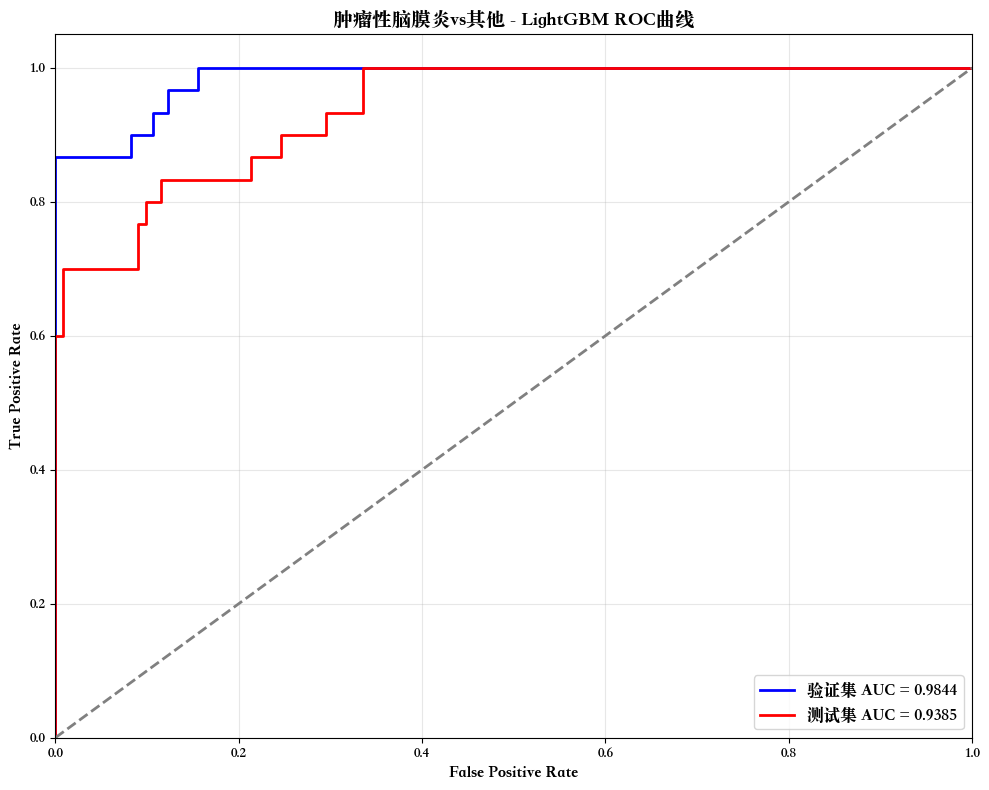

(452, 218) (152, 218)
Index(['血_13-β-D-葡聚糖_定量', '血_半乳甘露聚糖_定量', '血_细胞CD3-CD19+百分比_定量',
       '血_细胞CD3+百分比_定量', '血_细胞CD3+CD4+百分比_定量', '血_细胞CD4+/CD8+_定量',
       '血_细胞CD3+CD8+百分比_定量', '血_细胞CD3-CD16+CD56+百分比_定量', '血_肌酸激酶MB型质量法_定量',
       '血_B型钠尿肽前体_定量',
       ...
       '脑脊液_嗜酸性粒细胞百分比_定量', '脑脊液_幼稚淋巴细胞_定量', '脑脊液_浆细胞_定量', '脑脊液_中性粒细胞百分比_定量',
       '脑脊液_淋巴细胞百分比_定量', '脑脊液_巨噬细胞百分比_定量', '脑脊液_单个核细胞百分比_定量',
       '脑脊液_多个核细胞百分比_定量', 'gender', 'age'],
      dtype='object', length=218)

===== SHAP 特征重要性 (柱状图):  =====


/opt/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


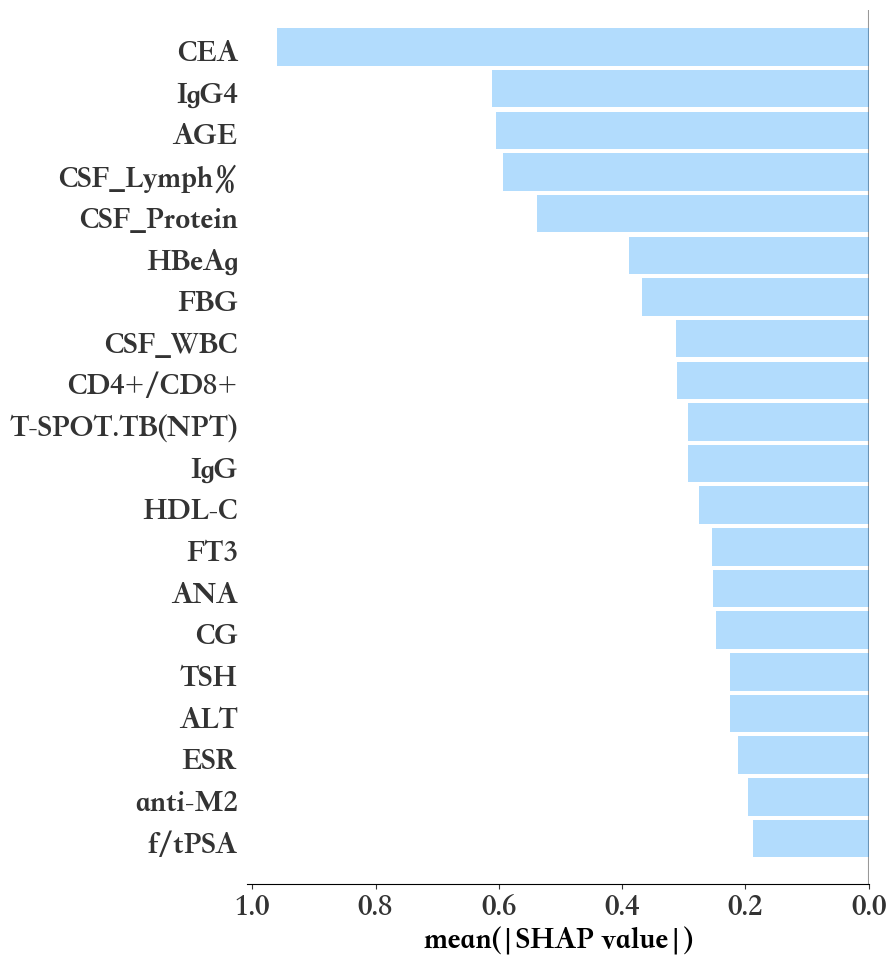


===== SHAP 特征分布 (蜂群图): =====


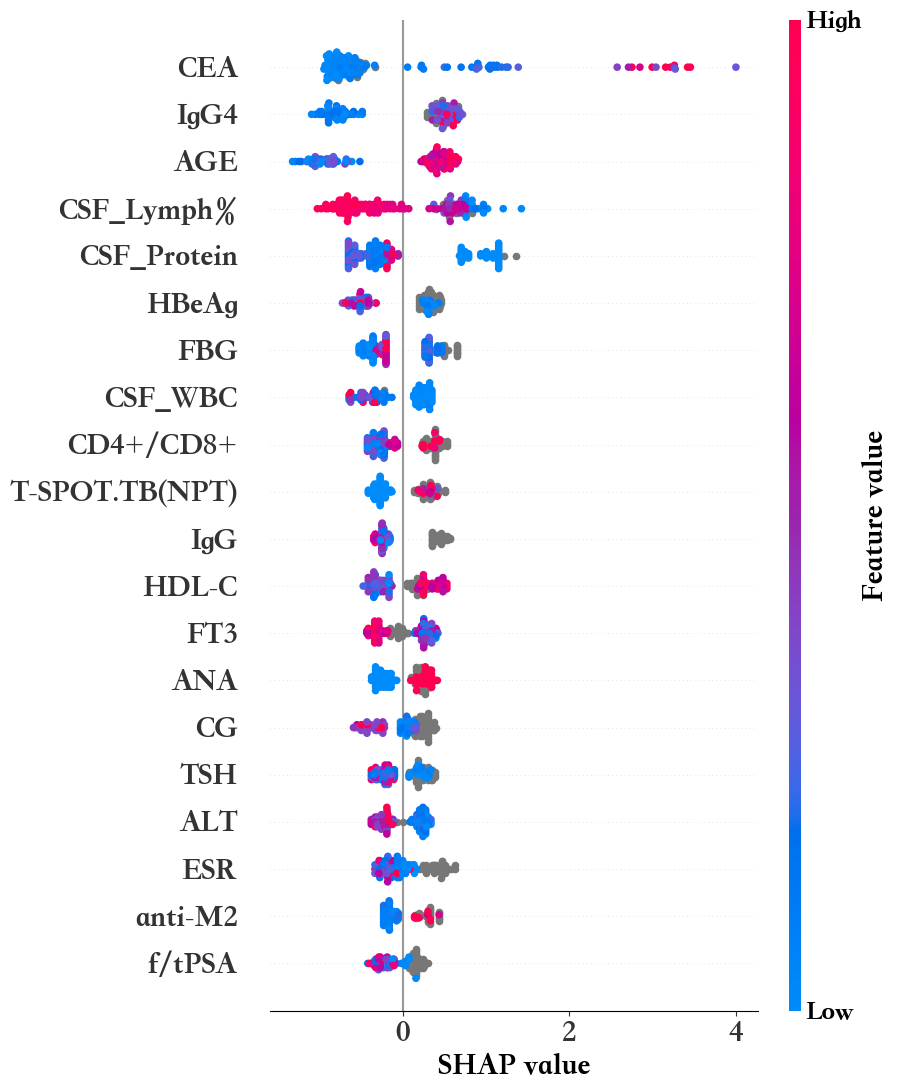

In [ ]:

filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性脑膜炎vs非感染性脑膜炎': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }
data_shape = {}

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)

def run_model(key, item, selected_df, current_dataset, data_shape):
    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]

    # 删除数值一样的列  
    selected_df = delete_same_col(selected_df)

    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]

    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]
    
    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)


    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])
    
    # 创建 LightGBM 数据集（可以提高训练效率）
    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    # print(X_train.shape,X_test.shape)
    # 得到最优模型
    result = train(X_train, y_train, X_val, y_val)
    final_model = result[0]

    # 评估验证集和测试集
    val_results = evaluate_model(final_model, X_val, y_val, "验证", key)
    test_results = evaluate_model(final_model, X_test, y_test, "测试", key)    
    
    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, val_results, test_results, key, current_dataset)

    # 绘制shap图
    draw_shap(final_model, X_train, X_test, current_dataset, key)
    return result[2]

filtered_df1 = filtered_df.copy()

if extract_integers(data_path)[-1] == 2:
    # print(list(filtered_df1.columns))
    selected_features = {
        '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体IgM_定量', '分组', '组名']],
        '感染性脑膜炎vs非感染性脑膜炎': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞CD3+CD8+百分比_定量','分组', '组名']],
        '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
finish = 0
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    filtered_df2 = filtered_df.copy()
    result_para = run_model(key, item, filtered_df2, current_dataset, data_shape)

     # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9, data_shape)

        

